In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

c:\Users\hp\AppData\Local\Programs\Python\Python38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Veri setini yükleyelim
df = pd.read_csv('AirPassengers.csv')

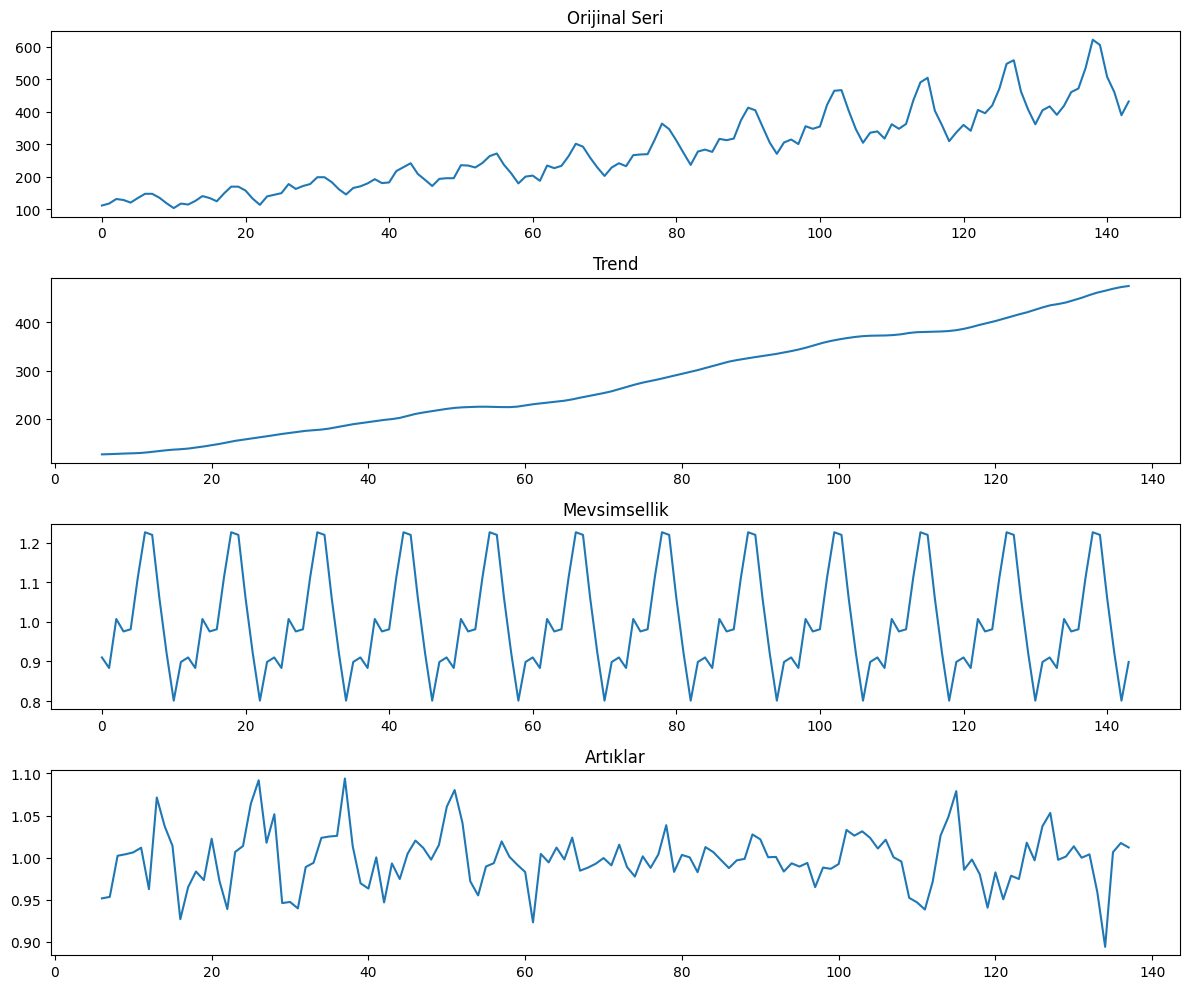

In [3]:
# Bileşenlere ayırma
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative',period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Orijinal Seri')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Mevsimsellik')
decomposition.resid.plot(ax=axes[3], title='Artıklar')
plt.tight_layout()
plt.show()

In [4]:
# Sütun isimlerini kontrol et
print(df.head())
print(df.columns)

# Prophet'ın gerektirdiği formata dönüştürelim
df.rename(columns={'Month': 'ds', 'Passengers': 'y'}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'])


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Index(['Month', 'Passengers'], dtype='object')


In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f"\n{name} - ADF Testi Sonuçları:")
    print(f"  Test İstatistiği: {result[0]:.4f}")
    print(f"  p-değeri: {result[1]:.4f}")
    
    if result[1] < 0.05:
        print("  → Seri durağan (H0 reddedildi)")
    else:
        print("  → Seri durağan değil (H0 reddedilemedi)")

# Test et
adf_test(df['y'], "Orijinal Seri")



Orijinal Seri - ADF Testi Sonuçları:
  Test İstatistiği: 0.8154
  p-değeri: 0.9919
  → Seri durağan değil (H0 reddedilemedi)


In [6]:
# Veri temizliği
df = df.dropna()  # NaN değerleri kaldır

# Train/Test Split
train = df[:-12]  # Son 12 ay test için
test = df[-12:]

# Modeli oluşturalım
model = Prophet(
    yearly_seasonality=True,   # Yıllık mevsimsellik var
    daily_seasonality=False,   # Günlük mevsimsellik yok
    weekly_seasonality=False   # Haftalık mevsimsellik yok
)

# Modeli eğitelim
model.fit(train)


# Tahmin yapalım
forecast = model.predict(test[['ds']])

# Performansı ölçelim
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(test['y'], forecast['yhat']))
mae = mean_absolute_error(test['y'], forecast['yhat'])
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")


# Gelecek tahminleri yap
future = model.make_future_dataframe(periods=12, freq='MS')
future_forecast = model.predict(future)
print("--- Gelecek Tahminleri ---")
print(future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))


23:03:52 - cmdstanpy - INFO - Chain [1] start processing
23:03:52 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 43.07, MAE: 33.44
--- Gelecek Tahminleri ---
            ds        yhat  yhat_lower  yhat_upper
132 1960-01-01  424.858234  398.740431  450.194582
133 1960-02-01  421.466469  396.673978  447.600893
134 1960-03-01  457.006423  430.845119  480.533428
135 1960-04-01  451.358637  426.273044  477.228150
136 1960-05-01  453.883376  429.136838  479.469019
137 1960-06-01  493.714480  468.534357  518.888505
138 1960-07-01  523.838497  499.158071  550.130308
139 1960-08-01  527.284229  501.023001  551.242005
140 1960-09-01  486.033720  459.649273  511.302986
141 1960-10-01  452.384713  427.286058  477.664354
142 1960-11-01  422.547803  395.785735  446.733332
143 1960-12-01  447.845113  422.329488  473.407089


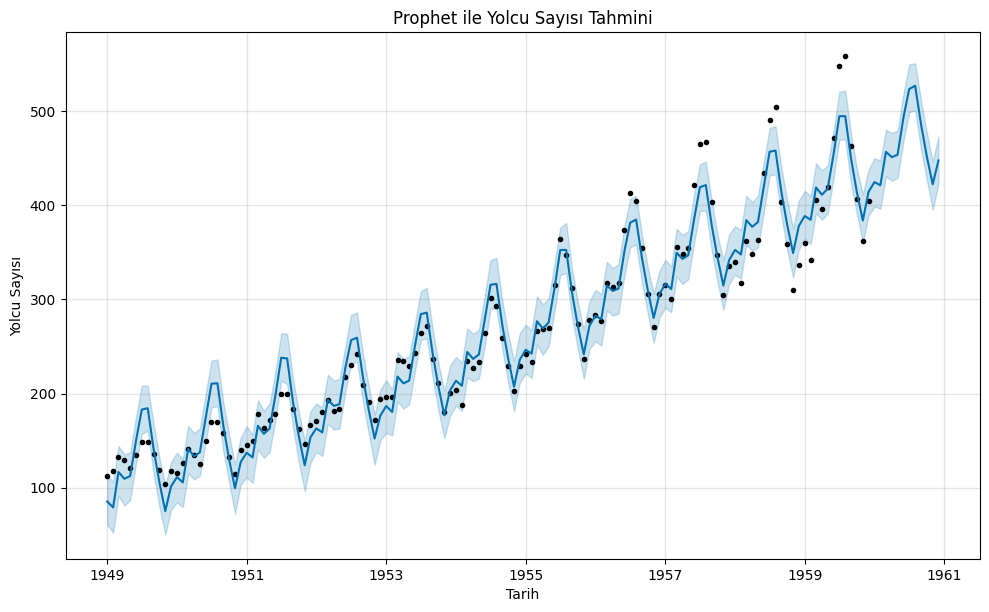

In [7]:
# Tahmin grafiği
fig1 = model.plot(future_forecast)
plt.title('Prophet ile Yolcu Sayısı Tahmini')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı')
plt.show()

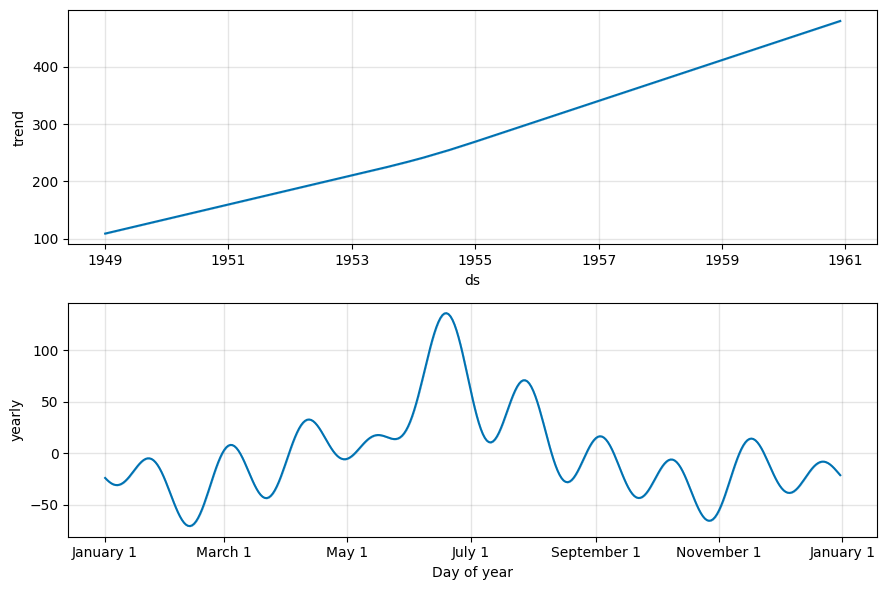

In [8]:
# Bileşen grafikleri
fig2 = model.plot_components(future_forecast)
plt.show()